In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()
rdf.group_by("model").agg(pl.len()).sort("len", descending=True).collect()

/tmp/ipykernel_45402/2816554591.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


model,len
str,u32
"""mr-hydra""",640
"""u-rstsf""",640
"""catch22""",640
"""quant""",640
"""rdst""",640
"""rstsf""",640
"""stacker-v4-r1""",521
"""hivecotev2""",145
"""stacker-v4-r3""",23


In [3]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")


).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""MiddlePhalanxTW""","""catch22""",400,false,0.519481
"""Trace""","""u-rstsf""",400,false,1.0
"""SemgHandMovementCh2""","""mr-hydra""",300,false,0.771111
"""MixedShapesSmallTrain""","""catch22""",400,false,0.861856
"""FaceFour""","""mr-hydra""",100,false,0.943182
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [4]:
from aeon.visualisation import plot_critical_difference

In [5]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,catch22,u-rstsf,mr-hydra,stacker-v4-r1,quant,rdst,rstsf,hivecotev2
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Trace""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""SemgHandMovementCh2""",0.797778,0.835111,0.757333,0.854667,0.834222,0.699111,0.855556,0.877778
"""MixedShapesSmallTrain""",0.861608,0.904825,0.966763,0.966392,0.928082,0.966928,0.908948,0.960412
"""FaceFour""",0.609091,0.945455,0.947727,0.997159,0.975,0.988636,0.995455,0.988636
"""MoteStrain""",0.871406,0.939137,0.94377,0.926717,0.946645,0.928275,0.948083,0.963259
…,…,…,…,…,…,…,…,…
"""FaceAll""",0.761775,0.764379,0.80568,0.801923,0.77503,0.798225,0.888994,0.856213
"""MiddlePhalanxOutlineCorrect""",0.766323,0.843299,0.851546,0.859966,0.848797,0.839175,0.845361,0.848797
"""SemgHandGenderCh2""",0.919667,0.934667,0.956,0.961667,0.951667,0.919667,0.972667,0.952778


(<Figure size 600x270 with 1 Axes>, <Axes: >)

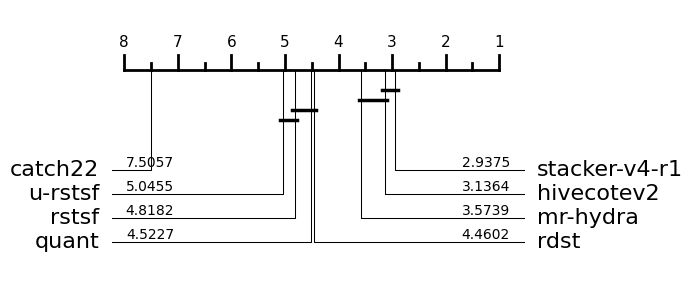

In [6]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [ ]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [ ]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,catch22,u-rstsf,mr-hydra,stacker-v4-r1,quant,rdst,rstsf,hivecotev2,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.708661,0.864567,0.858268,0.863517,0.867717,0.848819,0.870866,0.897638,17,127,2,288
"""InsectEPGSmallTrain""",0.976707,1.0,1.0,1.0,1.0,0.991968,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.968254,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BirdChicken""",0.86,0.91,0.9,0.9,0.9,0.9,0.95,0.9,20,20,2,512
"""Chinatown""",0.93586,0.984257,0.977259,0.979592,0.980758,0.977843,0.979009,0.982507,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…
"""UWaveGestureLibraryX""",0.761865,0.841039,0.871245,0.875098,0.844556,0.855388,0.825349,0.856784,896,3582,8,315
"""UWaveGestureLibraryY""",0.703853,0.76622,0.808208,0.811279,0.770966,0.764098,0.751982,0.777499,896,3582,8,315
"""UWaveGestureLibraryZ""",0.700223,0.779174,0.819989,0.821385,0.78928,0.798325,0.773479,0.795366,896,3582,8,315


48


(<Figure size 600x270 with 1 Axes>, <Axes: >)

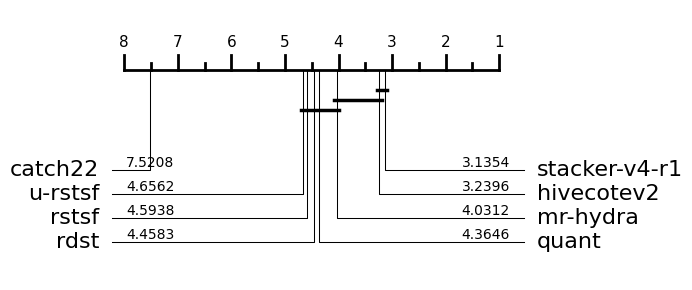

In [ ]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

27


(<Figure size 600x270 with 1 Axes>, <Axes: >)

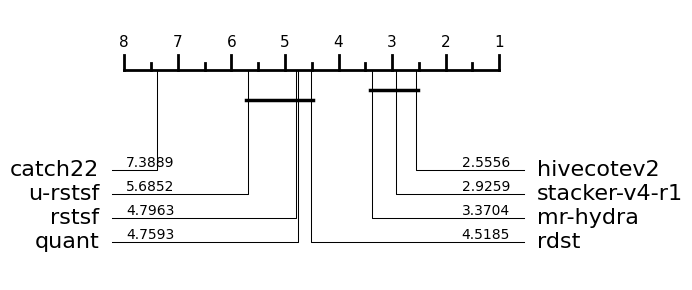

In [ ]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

10


(<Figure size 600x270 with 1 Axes>, <Axes: >)

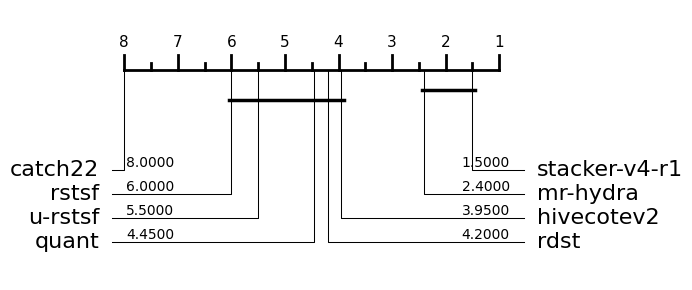

In [ ]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [ ]:
s_large

dataset,catch22,u-rstsf,mr-hydra,stacker-v4-r1,quant,rdst,rstsf,hivecotev2,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""MiddlePhalanxOutlineCorrect""",0.766323,0.843299,0.851546,0.859966,0.848797,0.839175,0.845361,0.848797,600,291,2,80
"""ProximalPhalanxOutlineCorrect""",0.837113,0.90378,0.919588,0.920103,0.907904,0.886598,0.913402,0.896907,600,291,2,80
"""ShapesAll""",0.793333,0.862333,0.927333,0.925833,0.873667,0.920667,0.856333,0.916667,600,600,60,512
"""Strawberry""",0.925405,0.962703,0.974595,0.975676,0.969189,0.976216,0.966486,0.978378,613,370,2,235
"""UWaveGestureLibraryAll""",0.826968,0.96756,0.979732,0.980458,0.967281,0.979788,0.958571,0.975712,896,3582,8,945
"""UWaveGestureLibraryX""",0.761865,0.841039,0.871245,0.875098,0.844556,0.855388,0.825349,0.856784,896,3582,8,315
"""UWaveGestureLibraryY""",0.703853,0.76622,0.808208,0.811279,0.770966,0.764098,0.751982,0.777499,896,3582,8,315
"""UWaveGestureLibraryZ""",0.700223,0.779174,0.819989,0.821385,0.78928,0.798325,0.773479,0.795366,896,3582,8,315
"""HandOutlines""",0.862162,0.915676,0.94973,0.947748,0.922703,0.948649,0.912973,0.937838,1000,370,2,2709


In [ ]:
import ray
ray.shutdown()